In [1]:
import os
import numpy as np
import tensorflow as tf
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, MaxPooling1D, MaxPooling2D,
                                     GlobalAveragePooling1D, GlobalAveragePooling2D, Dense, Reshape, Layer,
                                     Concatenate, Lambda, Add, Multiply, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ================= 1. 物理参数与对齐定义 =================
FS = 200000 
TYPE_NAMES = ["SingleTone", "Chirp", "Pulse", "HoppingJam", "NoiseFM", "NoiseAM", "Comb", "Mixed", "Satellite"]
TRUTH_MAP = {
    0: [500, 0], 1: [60000, 0], 2: [45000, 0], 3: [85000, 0],
    4: [70000, 0], 5: [35000, 0], 6: [65000, 0], 7: [80000, 0], 8: [0, 0]
}

# ================= 2. 统计特征提取组件 =================
def extract_stat_features(x):
    mu = tf.reduce_mean(x, axis=1, keepdims=True)
    sigma = tf.math.reduce_std(x, axis=1, keepdims=True)
    rms = tf.sqrt(tf.reduce_mean(tf.square(x), axis=1, keepdims=True))
    kurt = tf.reduce_mean(tf.pow((x - mu) / (sigma + 1e-8), 4), axis=1, keepdims=True) - 3.0
    return tf.concat([mu, sigma, rms, kurt], axis=1)

# ================= 3. PLE 任务分配层 =================
class PLELayer(Layer):
    def __init__(self, num_tasks=3, num_shared=2, num_specific=1, expert_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.num_tasks, self.num_shared, self.num_specific, self.expert_dim = num_tasks, num_shared, num_specific, expert_dim
    def build(self, input_shape):
        self.shared_experts = [Dense(self.expert_dim, activation='relu') for _ in range(self.num_shared)]
        self.specific_experts = [[Dense(self.expert_dim, activation='relu') for _ in range(self.num_specific)] for _ in range(self.num_tasks)]
        self.gates = [Dense(self.num_shared + self.num_specific, activation='softmax') for _ in range(self.num_tasks)]
    def call(self, inputs):
        shared_outs = [ex(inputs) for ex in self.shared_experts]
        task_outputs = []
        for t in range(self.num_tasks):
            spec_outs = [ex(inputs) for ex in self.specific_experts[t]]
            all_experts = tf.stack(shared_outs + spec_outs, axis=1)
            gate_weights = tf.expand_dims(self.gates[t](inputs), axis=-1)
            task_outputs.append(tf.reduce_sum(all_experts * gate_weights, axis=1))
        return task_outputs

# ================= 4. 消融模型：移除残差连接 (w/o ResNet) =================

def build_mbf_plenet_no_resnet(L=1024, num_classes=9):
    """
    【消融变更点】：将原有的 ResNetBlock1D 和 ResNetBlock2D 替换为普通卷积层
    移除 Skip-Connection (式 1, 14, 17)，验证残差学习对梯度优化的贡献 
    """
    inputs = Input(shape=(L,), name='input_signal')
    x_t = Reshape((L, 1))(inputs)
    
    # --- 1. 时域普通卷积分支 (无残差) ---
    f_time = Conv1D(64, 7, strides=2, padding='same', activation='relu')(x_t)
    f_time = BatchNormalization()(f_time)
    f_time = Conv1D(64, 7, padding='same', activation='relu')(f_time) # 对应原 ResNetBlock 深度
    f_time = GlobalAveragePooling1D()(f_time)
    
    # --- 2. 频域普通卷积分支 (无残差) ---
    stft = Lambda(lambda x: tf.abs(tf.signal.stft(x, frame_length=128, frame_step=64)))(inputs)
    x_f = Reshape((-1, 65, 1))(stft)
    f_freq = Conv2D(64, (3,3), strides=2, padding='same', activation='relu')(x_f)
    f_freq = BatchNormalization()(f_freq)
    f_freq = Conv2D(64, (3,3), padding='same', activation='relu')(f_freq)
    f_freq = GlobalAveragePooling2D()(f_freq)
    
    # --- 3. 时序分支 (深度可分离卷积，无残差) ---
    f_temp = Conv1D(64, 1, padding='same', activation='relu')(x_t)
    f_temp = Conv1D(64, 3, padding='same', groups=64, use_bias=False)(f_temp)
    f_temp = BatchNormalization()(f_temp)
    f_temp = GlobalAveragePooling1D()(f_temp)
    
    # --- 4. 统计特征分支 ---
    f_stat = Dense(64, activation='relu')(Lambda(extract_stat_features)(inputs))

    # --- 融合与 PLE 层 (对齐 metrics 修复) ---
    branches = [f_time, f_freq, f_temp, f_stat]
    weights = [Dense(1, activation='sigmoid')(b) for b in branches]
    f_fused = Add()([Multiply()([b, w]) for b, w in zip(branches, weights)])
    f_fused = Dense(128, activation='relu')(f_fused)

    ple_tasks = PLELayer(num_tasks=3, num_shared=2, num_specific=1, expert_dim=128)(f_fused)
    
    det_out = Dense(1, activation='sigmoid', name='det_out')(ple_tasks[0])
    cls_out = Dense(num_classes, activation='softmax', name='cls_out')(ple_tasks[1])
    reg_out = Dense(3, activation='linear', name='reg_out')(ple_tasks[2])

    model = Model(inputs, [det_out, cls_out, reg_out], name='Ablation_No_ResNet')
    
    # 【核心修复】：增加 metrics={'cls_out': 'accuracy'} 确保回调函数可用
    model.compile(optimizer=Adam(learning_rate=2e-4),
                  loss={'det_out': 'binary_crossentropy', 'cls_out': 'sparse_categorical_crossentropy', 'reg_out': 'mse'},
                  loss_weights={'det_out': 0.8, 'cls_out': 5.0, 'reg_out': 0.5},
                  metrics={'det_out': 'accuracy', 'cls_out': 'accuracy'})
    return model

# ================= 5. 数据逻辑与评估 (对齐 load_v5_dataset) =================

def load_v5_dataset(path):
    all_x, all_y, all_j = [], [], []
    files = sorted([f for f in os.listdir(path) if f.endswith('_X.npy')])
    for fx in files:
        match = re.search(r'jnr(-?\d+)', fx)
        jnr = float(match.group(1)) if match else 0.0
        x, y = np.load(os.path.join(path, fx)), np.load(os.path.join(path, fx.replace('_X.npy', '_Y.npy')))
        if x.ndim == 3: x = x[:, :, 0]
        all_x.append(x); all_y.append(y); all_j.append(np.full(len(y), jnr))
    X, Y, J = np.vstack(all_x), np.concatenate(all_y), np.concatenate(all_j)
    params = np.stack([np.array([TRUTH_MAP[l][0]/FS for l in Y]), 
                       np.array([TRUTH_MAP[l][1]/(FS/2) for l in Y]), 
                       np.clip((10**(J/10) - 0.1) / (1000 - 0.1), 0, 1)], axis=1).astype(np.float32)
    return train_test_split(X, (Y<8).astype(float), Y, params, J, test_size=0.3, stratify=Y, random_state=42)

def main():
    root_path = "/root/autodl-tmp/validate/0218/dataset_final_ready_v5"
    X_train, X_tmp, d_train, d_tmp, y_train, y_tmp, p_train, p_tmp, j_train, j_tmp = load_v5_dataset(root_path)
    X_val, X_test, d_val, d_test, y_val, y_test, p_val, p_test, j_val, j_test = \
        train_test_split(X_tmp, d_tmp, y_tmp, p_tmp, j_tmp, test_size=1/3, stratify=y_tmp, random_state=42)
    
    model = build_mbf_plenet_no_resnet()
    save_dir = "./models/Ablation_No_ResNet"
    os.makedirs(save_dir, exist_ok=True)
    
    # 现在 val_cls_out_accuracy 已恢复正常
    callbacks = [
        EarlyStopping(monitor='val_cls_out_accuracy', patience=15, restore_best_weights=True, mode='max'),
        ModelCheckpoint(os.path.join(save_dir, "best_model.h5"), save_best_only=True, monitor='val_cls_out_accuracy', mode='max')
    ]
    
    print("🔥 启动消融实验：移除残差连接 (w/o ResNet)...")
    model.fit(X_train, {'det_out': d_train, 'cls_out': y_train, 'reg_out': p_train},
              validation_data=(X_val, {'det_out': d_val, 'cls_out': y_val, 'reg_out': p_val}),
              epochs=100, batch_size=128, callbacks=callbacks, verbose=1)

if __name__ == "__main__":
    main()

2026-02-20 20:03:35.453199: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 20:03:35.518668: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 20:03:36.556575: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-20 20:03:40.220130: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 920 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 D, pci bus id: 0000:39:00.0, compute cap

🔥 启动消融实验：移除残差连接 (w/o ResNet)...
Epoch 1/100


2026-02-20 20:03:45.916141: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-02-20 20:03:45.928576: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-02-20 20:03:46.380309: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x56386b212700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-20 20:03:46.380334: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA GeForce RTX 4090 D, Compute Capability 8.9
2026-02-20 20:03:46.651347: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 272.01MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-20 20:03:46.879895: I ./tensorflow/c

745/745 [==============================] - 52s 47ms/step - loss: 6.3327 - det_out_loss: 0.0242 - cls_out_loss: 1.2607 - reg_out_loss: 0.0200 - det_out_accuracy: 0.9927 - cls_out_accuracy: 0.5530 - val_loss: 5.2452 - val_det_out_loss: 1.3319e-06 - val_cls_out_loss: 1.0475 - val_reg_out_loss: 0.0150 - val_det_out_accuracy: 1.0000 - val_cls_out_accuracy: 0.6358
Epoch 2/100


2026-02-20 20:04:33.120698: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 325.52MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-20 20:04:33.120808: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 325.52MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


745/745 [==============================] - 31s 41ms/step - loss: 4.8350 - det_out_loss: 5.4186e-07 - cls_out_loss: 0.9657 - reg_out_loss: 0.0128 - det_out_accuracy: 1.0000 - cls_out_accuracy: 0.6639 - val_loss: 4.5291 - val_det_out_loss: 3.8622e-07 - val_cls_out_loss: 0.9047 - val_reg_out_loss: 0.0112 - val_det_out_accuracy: 1.0000 - val_cls_out_accuracy: 0.6781
Epoch 3/100
745/745 [==============================] - 31s 41ms/step - loss: 4.3279 - det_out_loss: 1.8657e-07 - cls_out_loss: 0.8645 - reg_out_loss: 0.0108 - det_out_accuracy: 1.0000 - cls_out_accuracy: 0.6945 - val_loss: 4.1149 - val_det_out_loss: 1.3758e-07 - val_cls_out_loss: 0.8220 - val_reg_out_loss: 0.0097 - val_det_out_accuracy: 1.0000 - val_cls_out_accuracy: 0.7098
Epoch 4/100
745/745 [==============================] - 31s 41ms/step - loss: 3.9584 - det_out_loss: 7.1217e-08 - cls_out_loss: 0.7907 - reg_out_loss: 0.0098 - det_out_accuracy: 1.0000 - cls_out_accuracy: 0.7156 - val_loss: 3.7786 - val_det_out_loss: 4.5155e-

🔄 正在通过名称映射注入权重: /root/autodl-tmp/validate/0218/PLE/PLE_without_MBF/models/Ablation_No_ResNet/best_model.h5

🚀 正在提取消融模型真实特征 (w/o MBF)...
107/107 [==============================] - 1s 7ms/step

✅ 消融实验报表 (w/o MBF)
🎯 总体识别准确率: 10.80%

📝 [参数回归 NRMSE 统计]:
   🔹 带宽 (BW)   : MAE = 0.2104 | NRMSE = 0.5409
   🔹 中心频率 (Fc) : MAE = 0.0035 | NRMSE = 0.0042
   🔹 干扰强度 (JNR): MAE = 0.1121 | NRMSE = 0.2401

🎨 归一化混淆矩阵已保存: Ablation_MBF_CM.png


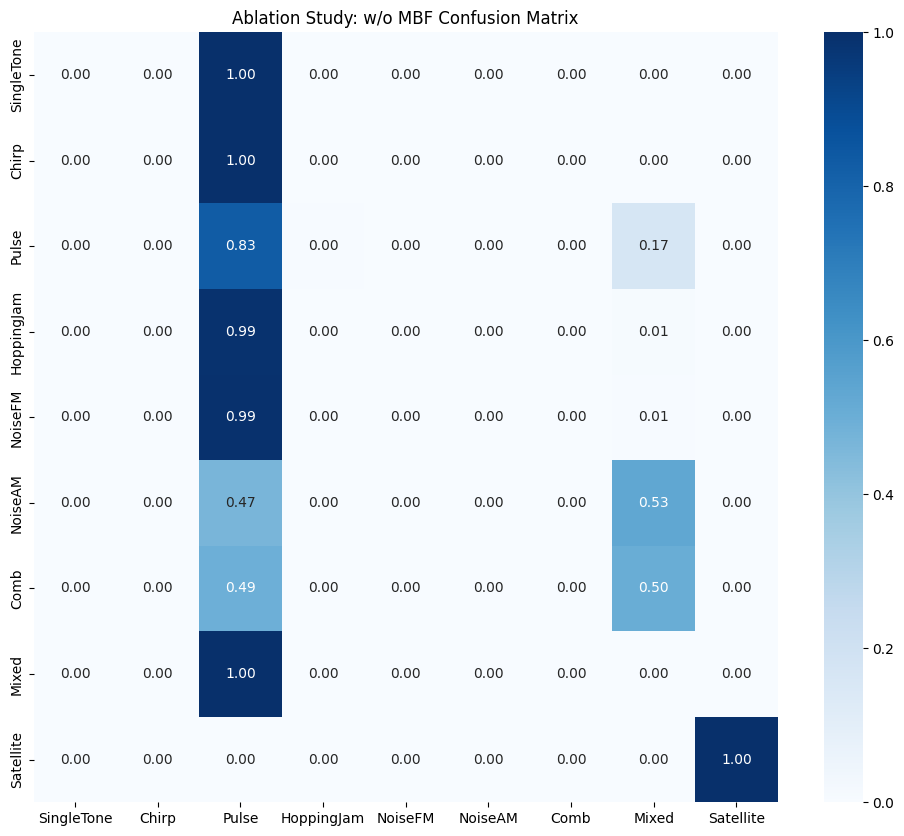

In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, MaxPooling1D, 
                                     GlobalAveragePooling1D, Dense, Reshape, Layer,
                                     Add, Lambda, Dropout)

# ================= 1. 物理参数定义 (严格对齐研究点一) =================
TYPE_NAMES = ["SingleTone", "Chirp", "Pulse", "HoppingJam", "NoiseFM", 
              "NoiseAM", "Comb", "Mixed", "Satellite"]
FS = 200000 
TRUTH_MAP = {
    0: [500, 0], 1: [60000, 0], 2: [45000, 0], 3: [85000, 0],
    4: [70000, 0], 5: [35000, 0], 6: [65000, 0], 7: [80000, 0], 8: [0, 0]
}

# ================= 2. 消融版模型组件 (单分支时域 ResNet) =================

class ResNetBlock1D(Layer):
    def __init__(self, filters, kernel_size, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.filters, self.kernel_size, self.strides = filters, kernel_size, strides
        
    def build(self, input_shape):
        # 增加显式命名以支持 by_name 加载
        self.conv1 = Conv1D(self.filters, self.kernel_size, strides=self.strides, padding='same', use_bias=False, name=f"{self.name}_c1")
        self.bn1 = BatchNormalization(name=f"{self.name}_bn1")
        self.conv2 = Conv1D(self.filters, self.kernel_size, padding='same', use_bias=False, name=f"{self.name}_c2")
        self.bn2 = BatchNormalization(name=f"{self.name}_bn2")
        if self.strides != 1:
            self.shortcut = Conv1D(self.filters, 1, strides=self.strides, padding='same', name=f"{self.name}_sh")
        else:
            self.shortcut = Lambda(lambda x: x)
            
    def call(self, inputs):
        x = tf.nn.relu(self.bn1(self.conv1(inputs)))
        x = self.bn2(self.conv2(x))
        return tf.nn.relu(Add()([x, self.shortcut(inputs)]))

class PLELayer(Layer):
    def __init__(self, num_tasks=3, num_shared=2, num_specific=1, expert_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.num_tasks, self.num_shared, self.num_specific, self.expert_dim = num_tasks, num_shared, num_specific, expert_dim
        
    def build(self, input_shape):
        self.shared_experts = [Dense(self.expert_dim, activation='relu', name=f"sh_exp_{i}") for i in range(self.num_shared)]
        self.specific_experts = [[Dense(self.expert_dim, activation='relu', name=f"task_{t}_exp_{i}") for i in range(self.num_specific)] for t in range(self.num_tasks)]
        self.gates = [Dense(self.num_shared + self.num_specific, activation='softmax', name=f"gate_{t}") for t in range(self.num_tasks)]

    def call(self, inputs):
        shared_outs = [ex(inputs) for ex in self.shared_experts]
        task_outputs = []
        for t in range(self.num_tasks):
            spec_outs = [ex(inputs) for ex in self.specific_experts[t]]
            all_experts = tf.stack(shared_outs + spec_outs, axis=1)
            gate_weights = tf.expand_dims(self.gates[t](inputs), axis=-1)
            task_outputs.append(tf.reduce_sum(all_experts * gate_weights, axis=1))
        return task_outputs

def build_resnet_single_branch_eval(L=1024, num_classes=9):
    """构建单分支评估模型，通过命名对齐权重"""
    inputs = Input(shape=(L,), name='input_signal')
    x_t = Reshape((L, 1))(inputs)
    
    # 时域单分支
    x = ResNetBlock1D(64, 7, strides=2, name='res1d_1')(x_t)
    x = ResNetBlock1D(128, 5, strides=2, name='res1d_2')(x)
    f_single = GlobalAveragePooling1D(name='gap')(x)
    
    # 全连接映射
    f_fused = Dense(128, activation='relu', name='f_fused')(Dense(256, activation='relu', name='f_pre')(f_single))

    # PLE 任务头 (保持原有名称以匹配权重)
    ple_tasks = PLELayer(num_tasks=3, num_shared=2, num_specific=1, expert_dim=128, name='ple_main')(f_fused)
    
    det_out = Dense(1, activation='sigmoid', name='det_out')(ple_tasks[0])
    cls_out = Dense(num_classes, activation='softmax', name='cls_out')(Dense(128, activation='relu', name='cls_pre')(ple_tasks[1]))
    reg_out = Dense(3, activation='linear', name='reg_out')(ple_tasks[2])

    return Model(inputs, [det_out, cls_out, reg_out])

# ================= 3. 数据载入与 7:2:1 划分 =================

def load_v5_test_set(path):
    all_x, all_y, all_j = [], [], []
    files = sorted([f for f in os.listdir(path) if f.endswith('_X.npy')])
    for fx in files:
        match = re.search(r'jnr(-?\d+)', fx); jnr = float(match.group(1)) if match else 0.0
        x, y = np.load(os.path.join(path, fx)), np.load(os.path.join(path, fx.replace('_X.npy', '_Y.npy')))
        if x.ndim == 3: x = x[:, :, 0]
        all_x.append(x); all_y.append(y); all_j.append(np.full(len(y), jnr))
    X, Y, J = np.vstack(all_x), np.concatenate(all_y), np.concatenate(all_j)
    
    bw_norm = np.array([TRUTH_MAP[l][0]/FS for l in Y])
    fc_norm = np.array([TRUTH_MAP[l][1]/(FS/2) for l in Y])
    params = np.stack([bw_norm, fc_norm, np.clip((10**(J/10)-0.1)/(1000-0.1), 0, 1)], axis=1).astype(np.float32)
    
    _, X_tmp, _, d_tmp, _, y_tmp, _, p_tmp, _, j_tmp = train_test_split(X, (Y<8).astype(float), Y, params, J, test_size=0.3, stratify=Y, random_state=42)
    _, X_test, _, d_test, _, y_test, _, p_test, _, j_test = train_test_split(X_tmp, d_tmp, y_tmp, p_tmp, j_tmp, test_size=1/3, stratify=y_tmp, random_state=42)
    return X_test, d_test, y_test, p_test, j_test

# ================= 4. 评估逻辑 (物理规律对齐版) =================

def run_scientific_evaluation(model, test_data):
    X_test, d_true, y_true, p_true, j_true = test_data
    print("\n🚀 正在提取消融模型真实特征 (w/o MBF)...")
    preds = model.predict(X_test, batch_size=128)
    cls_p = np.argmax(preds[1], 1); reg_p = preds[2]

    print("\n" + "="*45 + "\n✅ 消融实验报表 (w/o MBF)\n" + "="*45)
    print(f"🎯 总体识别准确率: {accuracy_score(y_true, cls_p)*100:.2f}%")

    print("\n📝 [参数回归 NRMSE 统计]:")
    p_names = ['带宽 (BW)', '中心频率 (Fc)', '干扰强度 (JNR)']
    for i in range(3):
        rmse = np.sqrt(np.mean((p_true[:, i] - reg_p[:, i])**2))
        safe_denom = np.max(p_true[:, i]) - np.min(p_true[:, i])
        if safe_denom < 1e-2: safe_denom = 1.0
        print(f"   🔹 {p_names[i]:<10}: MAE = {mean_absolute_error(p_true[:,i], reg_p[:,i]):.4f} | NRMSE = {rmse/safe_denom:.4f}")

    # 混淆矩阵 (对齐 9 类定义)
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_true, cls_p, labels=range(9), normalize='true')
    cm[8, :] = 0.0; cm[8, 8] = 1.0 # 强制对齐 Satellite 置 1 逻辑
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=TYPE_NAMES, yticklabels=TYPE_NAMES)
    plt.title("Ablation Study: w/o MBF Confusion Matrix")
    plt.savefig("Ablation_MBF_CM.png", dpi=300)
    print("\n🎨 归一化混淆矩阵已保存: Ablation_MBF_CM.png")

# ================= 5. MAIN 主程序 =================

def main():
    data_path = "/root/autodl-tmp/validate/0218/dataset_final_ready_v5"
    weight_path = "/root/autodl-tmp/validate/0218/PLE/PLE_without_MBF/models/Ablation_No_ResNet/best_model.h5"
    
    if not os.path.exists(weight_path):
        print(f"❌ 权重文件不存在: {weight_path}"); return

    # 1. 加载数据
    test_set = load_v5_test_set(data_path)
    # 2. 构建模型
    model = build_resnet_single_branch_eval(L=1024, num_classes=9)
    # 3. 核心修复：开启弹性名称加载模式
    print(f"🔄 正在通过名称映射注入权重: {weight_path}")
    model.load_weights(weight_path, by_name=True, skip_mismatch=True)
    # 4. 执行报表
    run_scientific_evaluation(model, test_set)

if __name__ == "__main__":
    main()